In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

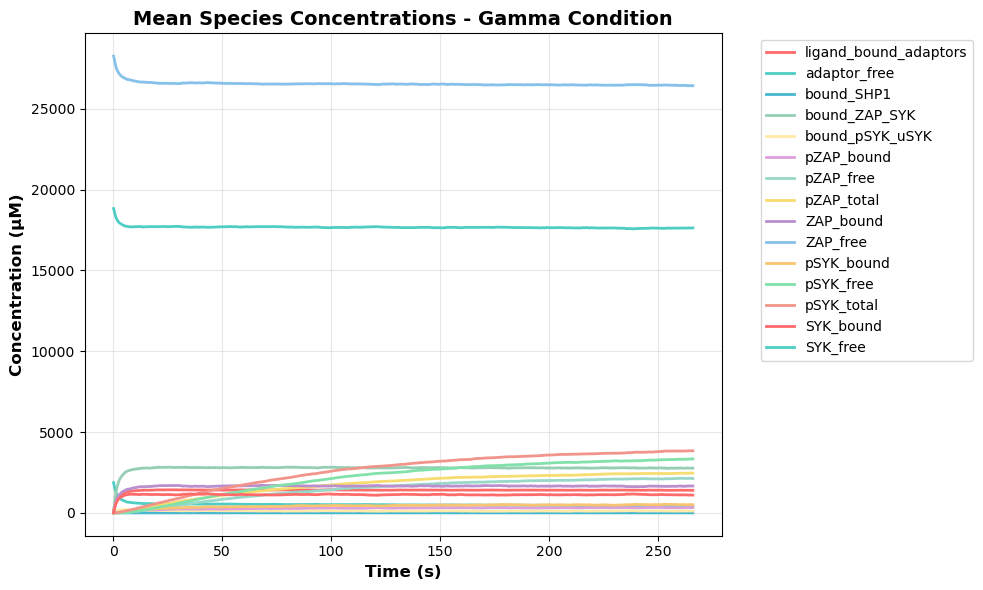

In [2]:
# Load and process data
directory = "gamma_runs/analysis/bng_output_"
data = [pd.read_csv(f"{directory}{i}/model.gdat", sep="\t", comment='#') for i in range(3)]

# Define proper column labels
# column_labels = ['PZAP_total', 'pSYK_total', 'pSYK_bound', 'pSYK_free', 
#                 'PZAP_bound', 'PZAP_free', 'bound_SHP1', 'gamma_bound', 'bound_ZAP','bound_SYK','bound_pSYK_uSYK',
#                 'adaptor_free', 'ligand_bound_complexes']

column_labels = ['ligand_bound_adaptors','adaptor_free','bound_SHP1','bound_ZAP_SYK', 'bound_pSYK_uSYK',
                 'pZAP_bound', 'pZAP_free', 'pZAP_total', 'ZAP_bound', 'ZAP_free',
                 'pSYK_bound', 'pSYK_free', 'pSYK_total', 'SYK_bound', 'SYK_free',
                 ]
               

# Stack data and compute means
stacked = np.stack([df.values for df in data])
means = np.mean(stacked, axis=0)
time = data[0].iloc[:, 0]

# Plot all columns (skip time column) - Gamma condition with unique colors
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9', '#F8C471', '#82E0AA', '#F1948A']
for i, label in enumerate(column_labels):
    plt.plot(time, means[:, i+1], label=label, color=colors[i % len(colors)], linewidth=2)

plt.xlabel("Time (s)", fontsize=12, fontweight='bold')
plt.ylabel("Concentration (μM)", fontsize=12, fontweight='bold')
plt.title("Mean Species Concentrations - Gamma Condition", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

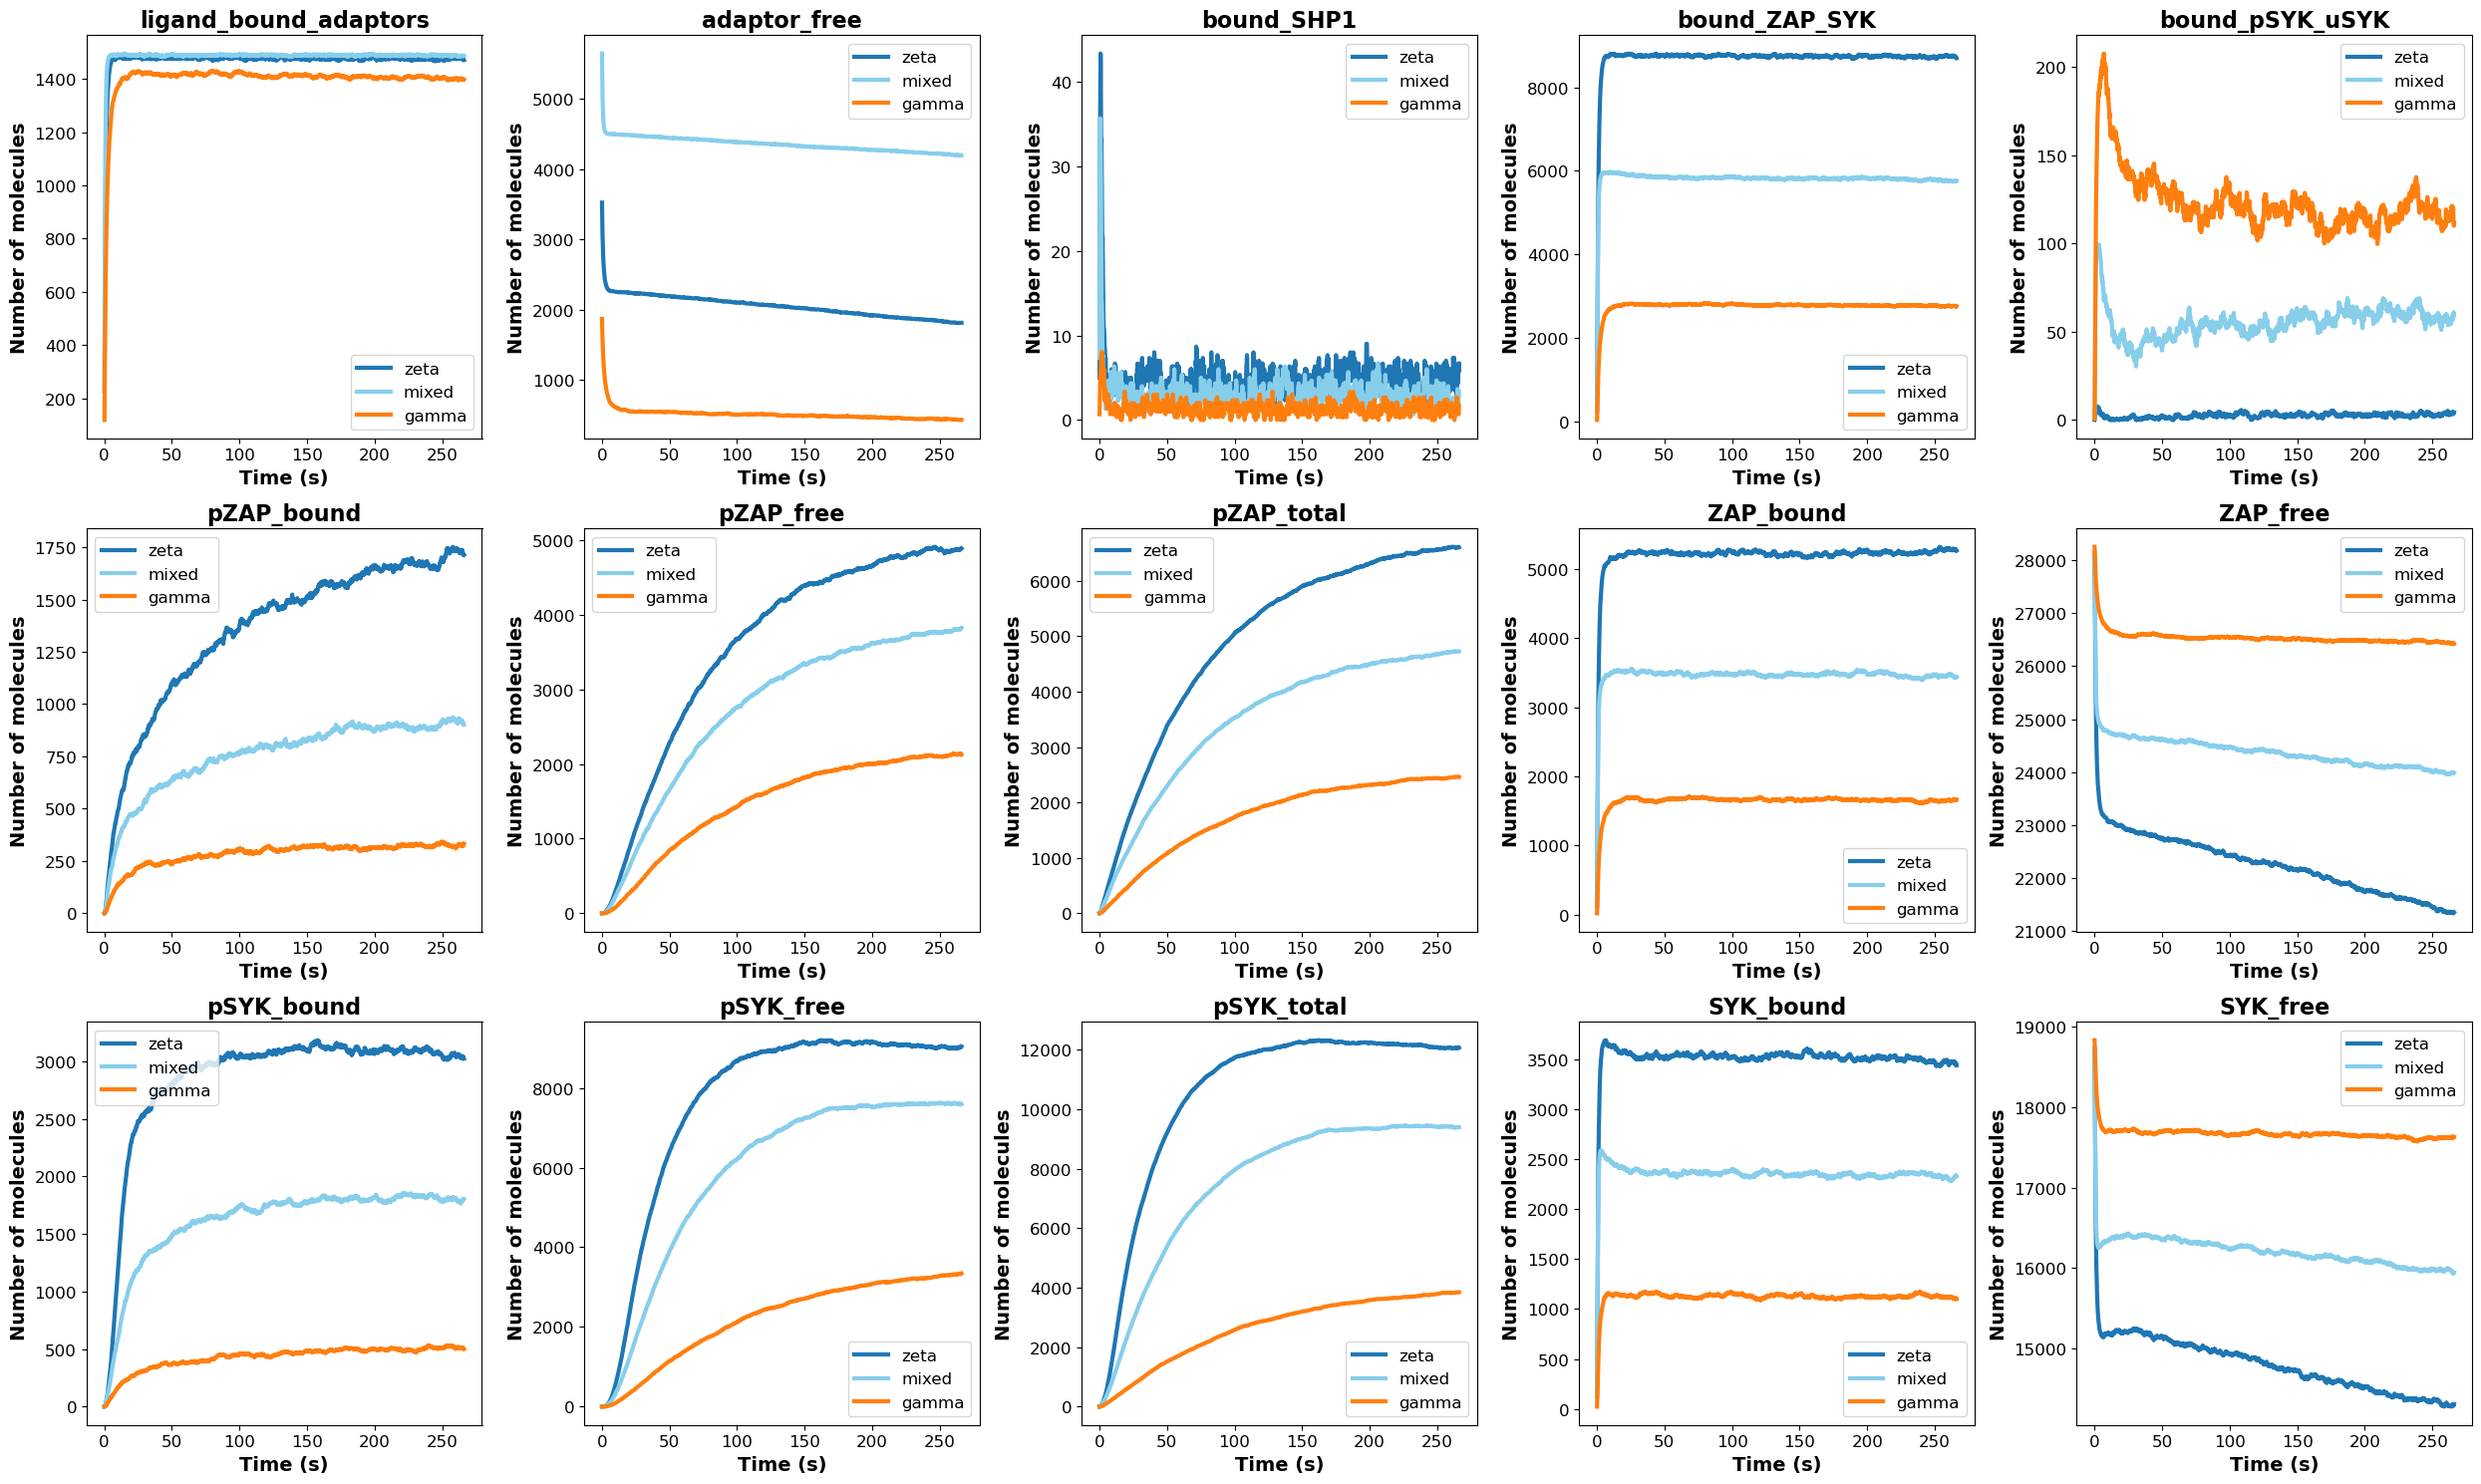

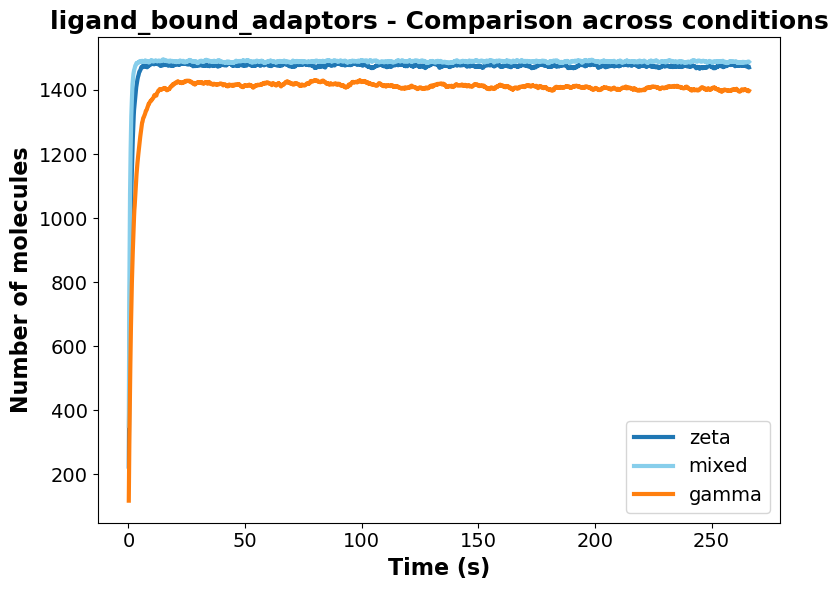

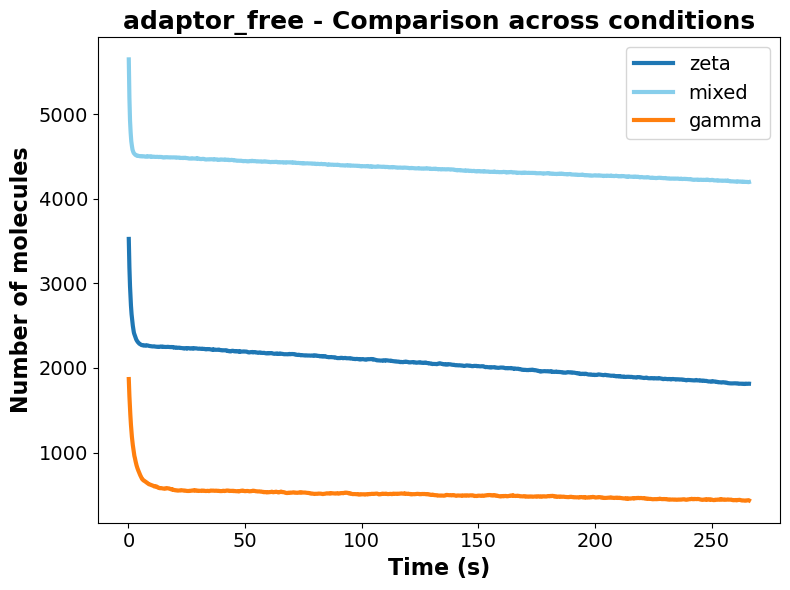

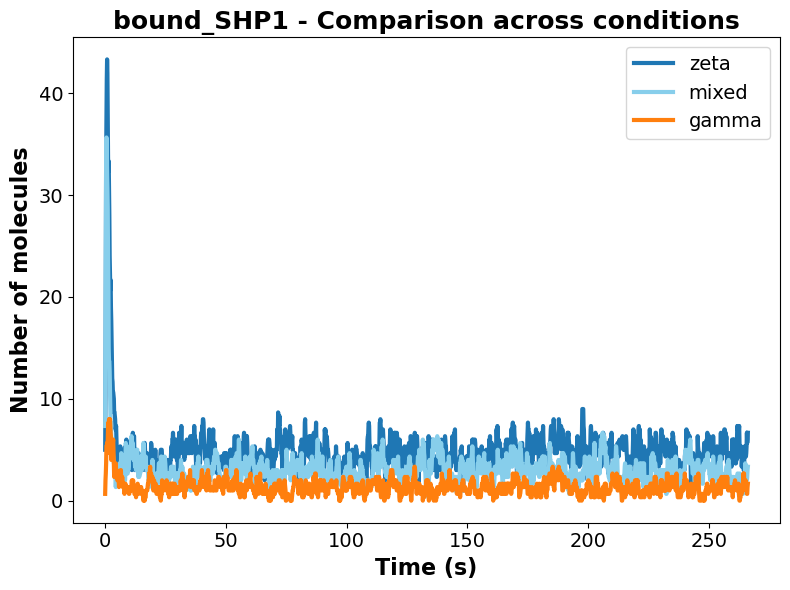

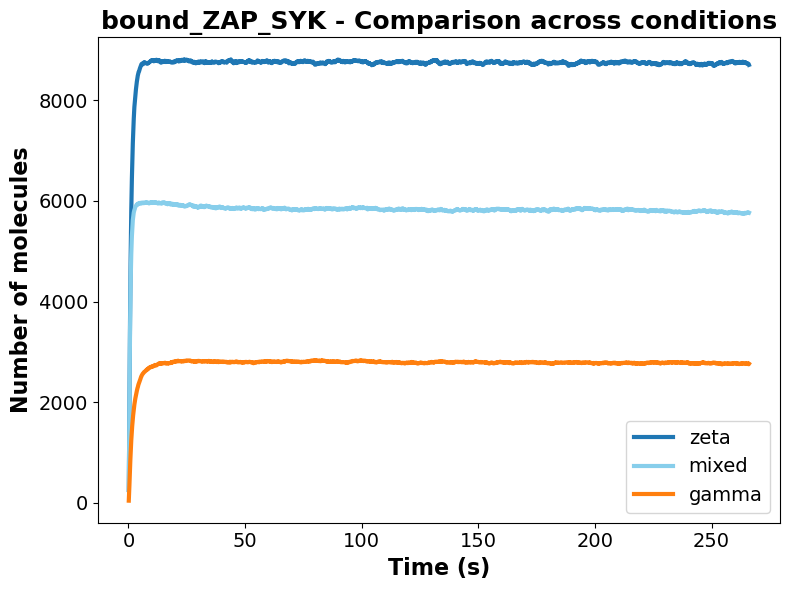

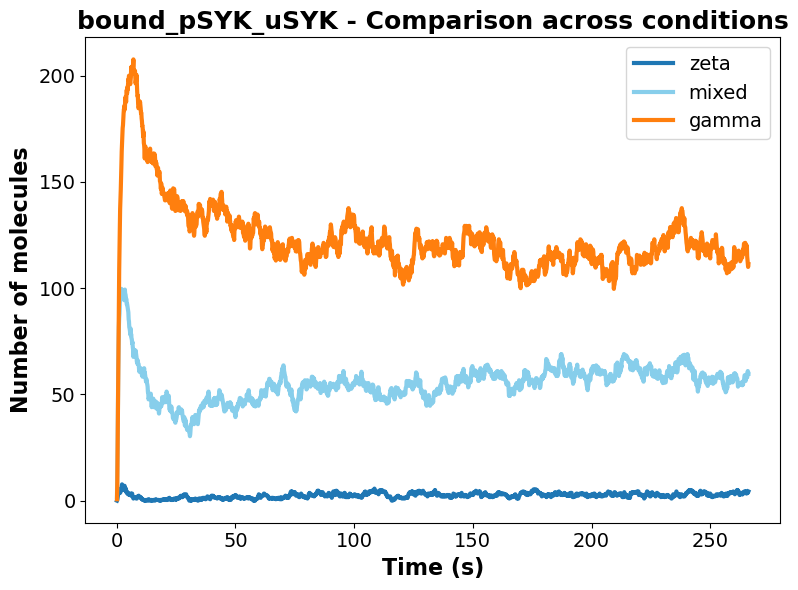

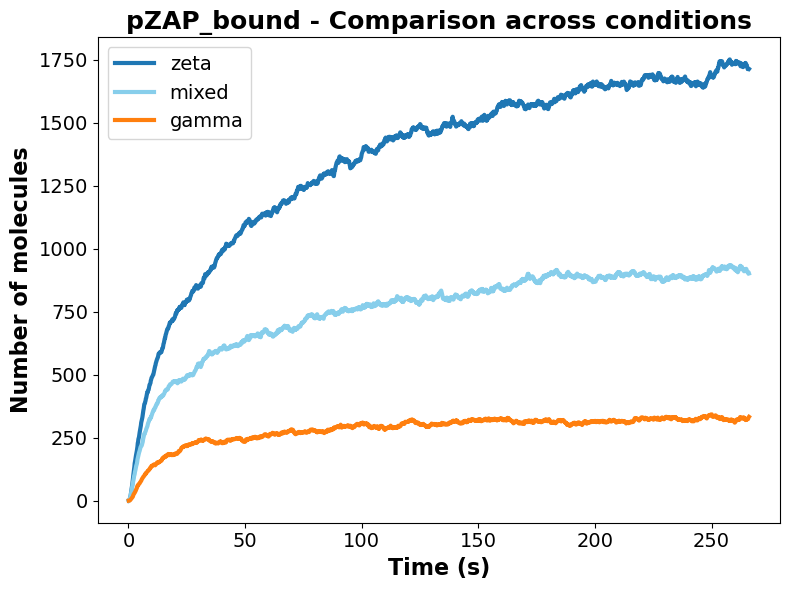

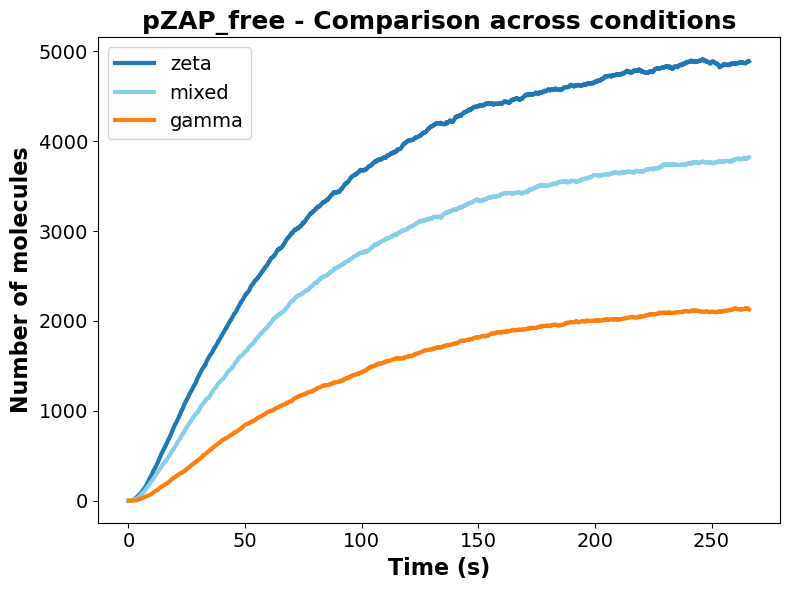

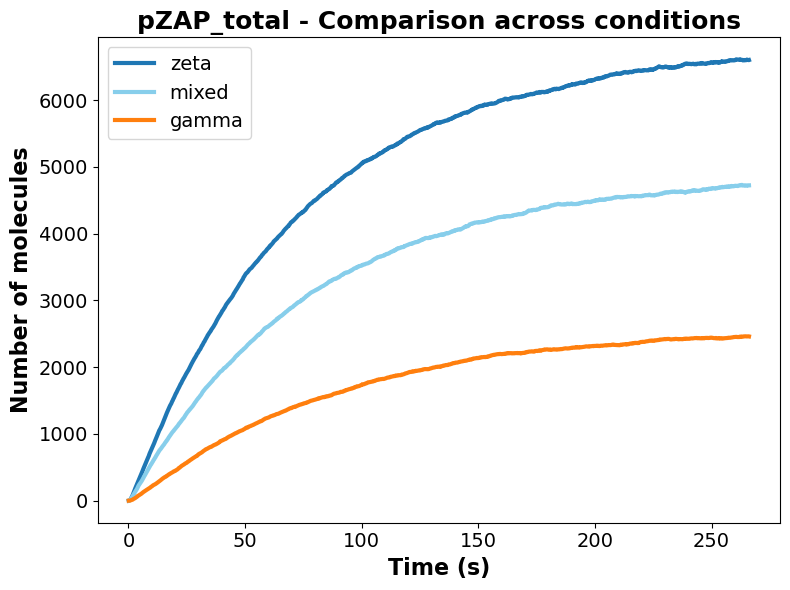

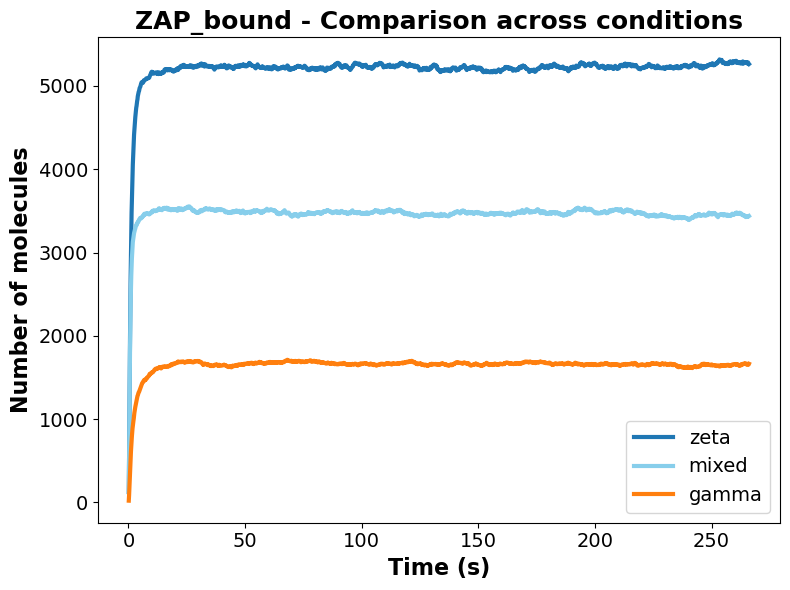

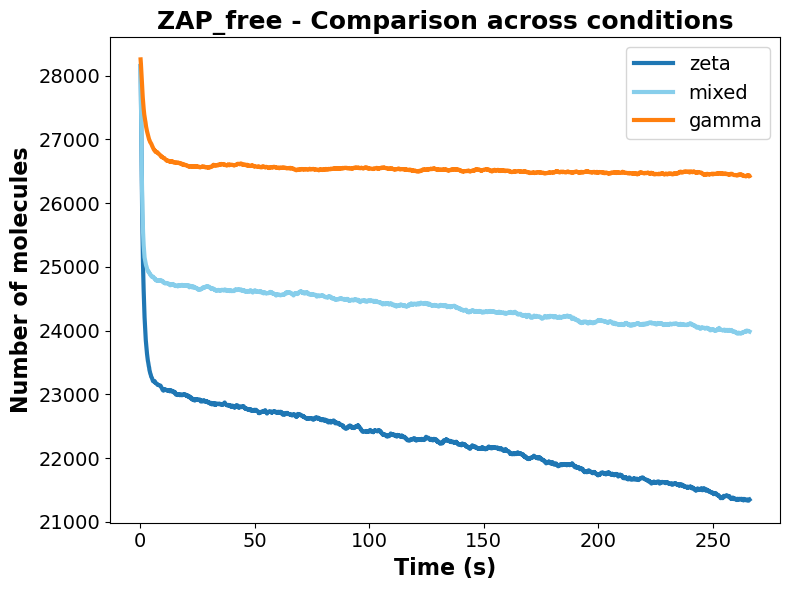

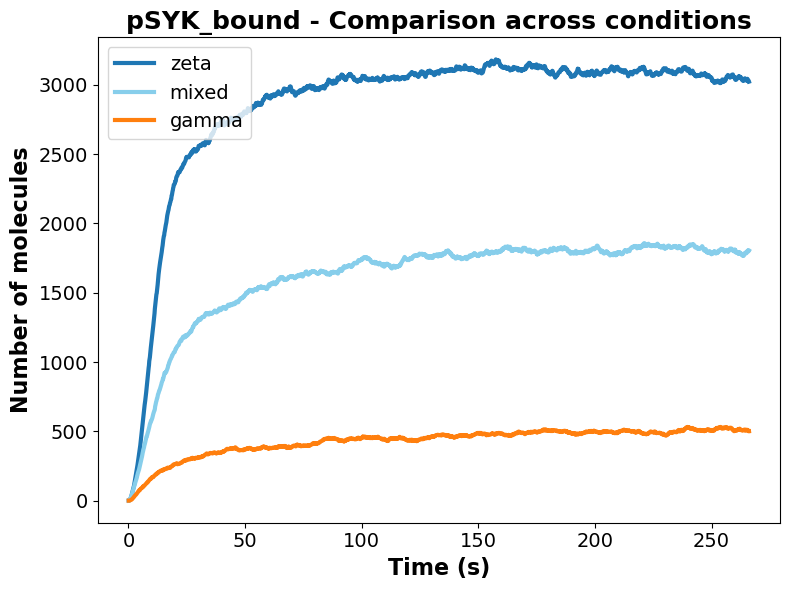

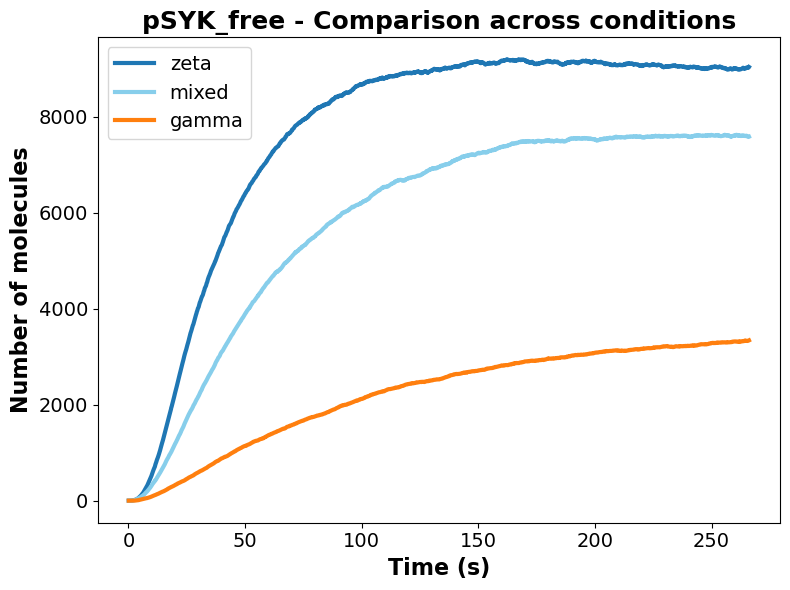

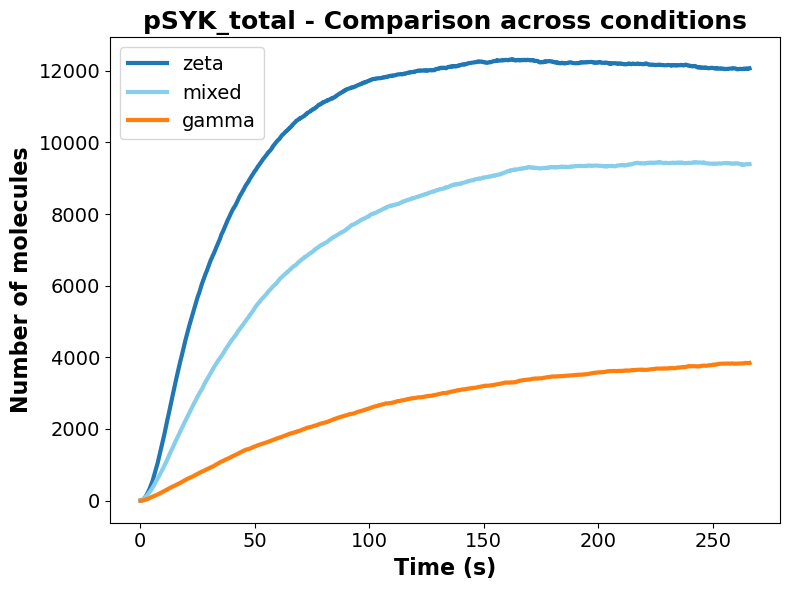

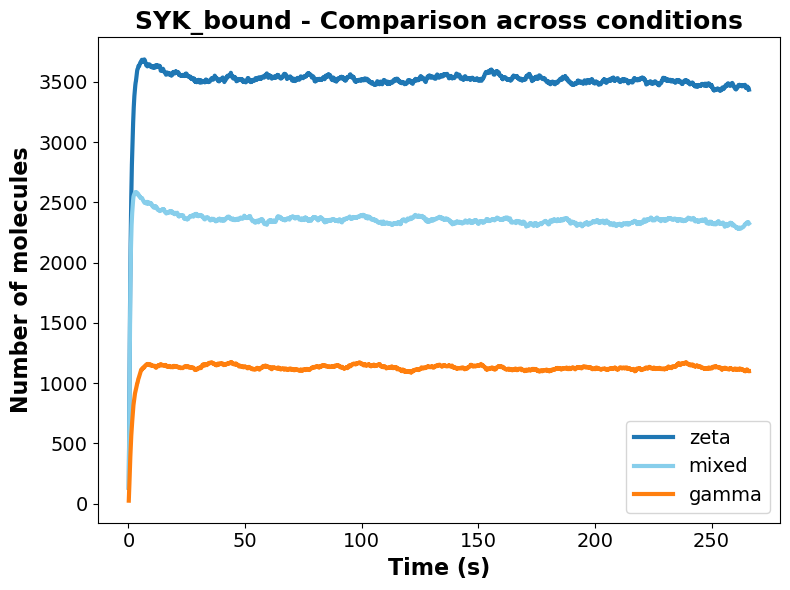

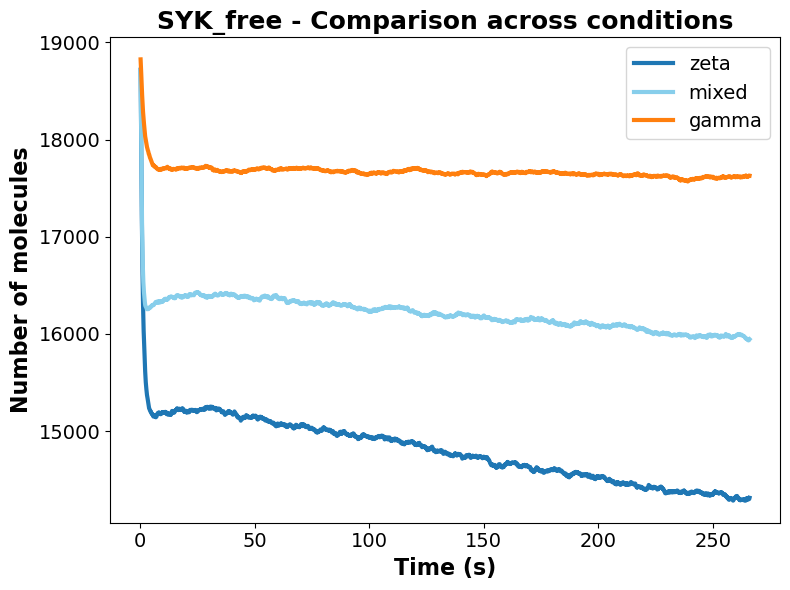

In [3]:
# Load data for all three conditions
directories = {
    'zeta': "zeta_runs/analysis/bng_output_",
    'mixed': "mixed_runs/analysis/bng_output_", 
    'gamma': "gamma_runs/analysis/bng_output_"
}

# Colors for each condition
colors = {'zeta': '#1f77b4', 'mixed': '#87ceeb', 'gamma': '#ff7f0e'}

# Column labels

column_labels = ['ligand_bound_adaptors','adaptor_free','bound_SHP1','bound_ZAP_SYK', 'bound_pSYK_uSYK',
                 'pZAP_bound', 'pZAP_free', 'pZAP_total', 'ZAP_bound', 'ZAP_free',
                 'pSYK_bound', 'pSYK_free', 'pSYK_total', 'SYK_bound', 'SYK_free',
                 ]
               
# Load and process data for all conditions
all_data = {}
for condition, directory in directories.items():
    data = [pd.read_csv(f"{directory}{i}/model.gdat", sep="\t", comment='#') for i in range(3)]
    stacked = np.stack([df.values for df in data])
    means = np.mean(stacked, axis=0)
    time = data[0].iloc[:, 0]
    all_data[condition] = {'time': time, 'means': means}

# Create subplot for each species - Updated to 3x5 grid to accommodate all 13 species
fig, axes = plt.subplots(3, 5, figsize=(25, 15))
axes = axes.flatten()

for i, species in enumerate(column_labels):
    ax = axes[i]
    
    # Plot each condition for this species
    for condition in ['zeta', 'mixed', 'gamma']:
        time = all_data[condition]['time']
        concentration = all_data[condition]['means'][:, i+1] 
        ax.plot(time, concentration, label=condition, color=colors[condition], linewidth=3)
    
    ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of molecules', fontsize=14, fontweight='bold')
    ax.set_title(species, fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    #ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Hide unused subplots (we have 13 species, so 2 empty subplots in 3x5 grid)
for j in range(len(column_labels), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Alternative: Individual plots for each species
for species_idx, species in enumerate(column_labels):
    plt.figure(figsize=(8, 6))
    
    for condition in ['zeta', 'mixed', 'gamma']:
        time = all_data[condition]['time']
        concentration = all_data[condition]['means'][:, species_idx+1] 
        plt.plot(time, concentration, label=condition, color=colors[condition], linewidth=3)
    
    plt.xlabel('Time (s)', fontsize=16, fontweight='bold')
    plt.ylabel('Number of molecules', fontsize=16, fontweight='bold')
    plt.title(f'{species} - Comparison across conditions', fontsize=18, fontweight='bold')
    plt.legend(fontsize=14)
    #plt.grid(True, alpha=0.3)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    plt.show()